In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("master_dataset_general.csv")

In [3]:
df.drop(columns= [
    'ReportType',
    'Y_Cost_Per_Ton',
    'AccessionNumber',
    'QuarterEnd', 
    "Tons_Shipped_thousands",
    "Inventories_millions",
    "COGS_millions",
    "Net_sales_millions",
    "Year"
    ], inplace=True)


In [4]:

def plot_financials_scaled(df):
    df = df.copy()

    cols_X = [c for c in df.columns if c.startswith("X")]
    
    # no x columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols = [c for c in num_cols if c not in cols_X]

    if 'PeriodEndDate' in df.columns:
        df['PeriodEndDate'] = pd.to_datetime(df['PeriodEndDate'])

    scaler = RobustScaler()
    scaled_values = scaler.fit_transform(df[num_cols])
    
    scaled_df = pd.DataFrame(scaled_values, columns=num_cols)
    scaled_df['PeriodEndDate'] = df['PeriodEndDate']
    
    # --- plot ---
    plt.figure(figsize=(15, 6))
    
    for col in num_cols:

        if col in ['Gross_Margin_Pct', 'Tons_Shipped']:
            lw = 0.8
        else:
            lw = 2.0
        plt.plot(scaled_df['PeriodEndDate'], scaled_df[col], label=col, linewidth=lw)
    
    plt.title("Financial Variables")
    plt.xlabel("Period End Date")
    plt.ylabel("Normalized Values")
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


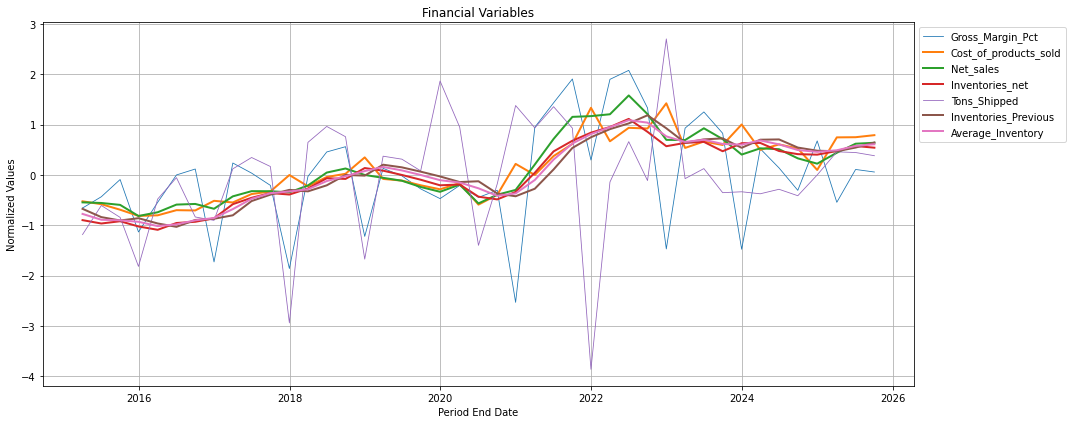

In [5]:
plot_financials_scaled(df)